## Data Preprocessing and Exploration

In [1]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans

import xgboost as xgb
import shap
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (LSTM, Dense, Input,
                                      Concatenate, Dropout)
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")


All libraries imported successfully.


In [2]:
# Load the ecommerce behaviour dataset

df = pd.read_csv('../data/jewelry.csv')
print("First five rows of the dataset:")
df.head()

First five rows of the dataset:


,2018-12-01 11:40:29 UTC,1924719191579951782,1842195256808833386,1,1806829201890738522,jewelry.earring,0,561.51,1515915625207851155,Unnamed: 9,red,gold,diamond
0,2018-12-01 17:38:31 UTC,1924899396621697920,1806829193678291446,1,1.806829e+18,NaN,NaN,212.14,1.515916e+18,NaN,yellow,gold,NaN
1,2018-12-02 13:53:42 UTC,1925511016616034733,1842214461889315556,1,1.806829e+18,jewelry.pendant,1.0,54.66,1.515916e+18,f,white,gold,sapphire
2,2018-12-02 17:44:02 UTC,1925626951238681511,1835566849434059453,1,1.806829e+18,jewelry.pendant,0.0,88.90,1.515916e+18,f,red,gold,diamond
3,2018-12-02 21:30:19 UTC,1925740842841014667,1873936840742928865,1,1.806829e+18,jewelry.necklace,0.0,417.67,1.515916e+18,NaN,red,gold,amethyst
4,2018-12-02 22:09:34 UTC,1925760595336888995,1835566854827934449,1,1.806829e+18,jewelry.earring,1.0,102.27,1.515916e+18,NaN,red,gold,NaN


In [5]:
# Load without header first to inspect

# Row 0 is the corrupted header — assign proper column names
df.columns = ['event_time', 'event_type_id', 'product_id',
                  'flag', 'user_id', 'category_code',
                  'cart_flag', 'price', 'brand_id',
                  'device_flag', 'color', 'material', 'stone']

# Drop the first row (was used as column names)
df = df.iloc[1:].reset_index(drop=True)

print("\nFixed columns:", df.columns.tolist())
print(f"Shape after header fix: {df.shape}")


Fixed columns: ['event_time', 'event_type_id', 'product_id', 'flag', 'user_id', 'category_code', 'cart_flag', 'price', 'brand_id', 'device_flag', 'color', 'material', 'stone']
Shape after header fix: (95909, 13)


In [6]:
# Dataset Info

print("Dataset Info:")
print("=" * 50)
df.info()

print("\nFirst 5 rows:")
print(df.head())

print("\nMissing values:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 95909 entries, 0 to 95908
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   event_time     95909 non-null  str    
 1   event_type_id  95909 non-null  int64  
 2   product_id     95909 non-null  int64  
 3   flag           95909 non-null  int64  
 4   user_id        90557 non-null  float64
 5   category_code  85977 non-null  str    
 6   cart_flag      91125 non-null  float64
 7   price          90557 non-null  float64
 8   brand_id       90557 non-null  float64
 9   device_flag    47743 non-null  str    
 10  color          88249 non-null  str    
 11  material       90447 non-null  str    
 12  stone          61852 non-null  str    
dtypes: float64(4), int64(3), str(6)
memory usage: 9.5 MB

First 5 rows:
                event_time        event_type_id           product_id  flag  \
0  2018-12-02 13:53:42 UTC  1925511016616034733  1842214461889315556     1   

In [7]:
# data Type Conversion

# Convert types
df['event_time'] = pd.to_datetime(df['event_time'], errors='coerce')
df['price']      = pd.to_numeric(df['price'],      errors='coerce')
df['user_id']    = pd.to_numeric(df['user_id'],    errors='coerce')
df['product_id'] = pd.to_numeric(df['product_id'], errors='coerce')
df['cart_flag']  = pd.to_numeric(df['cart_flag'],  errors='coerce')

print("Data types after conversion:")
print(df.dtypes)
print(f"\nDate range: {df['event_time'].min()} → {df['event_time'].max()}")
print(f"Unique users   : {df['user_id'].nunique():,}")
print(f"Unique products: {df['product_id'].nunique():,}")

Data types after conversion:
event_time       datetime64[us, UTC]
event_type_id                  int64
product_id                     int64
flag                           int64
user_id                      float64
category_code                    str
cart_flag                    float64
price                        float64
brand_id                     float64
device_flag                      str
color                            str
material                         str
stone                            str
dtype: object

Date range: 2018-12-02 13:53:42+00:00 → 2021-12-01 09:59:07+00:00
Unique users   : 25
Unique products: 9,613


In [21]:
# Data Cleaning

print("=== BEFORE CLEANING ===")
print(f"Total records   : {len(df):,}")
print(f"Missing values:\n{df.isnull().sum()}")

# 1. Drop rows with missing user_id
print(f"\nMissing user_id: {df['user_id'].isnull().sum():,}")
df.dropna(subset=['user_id'], inplace=True)

# 2. Drop rows with missing price
print(f"Missing price: {df['price'].isnull().sum():,}")
df.dropna(subset=['price'], inplace=True)

# 3. Drop rows with missing event_time
df.dropna(subset=['event_time'], inplace=True)

# 4. Remove negative or zero prices
print(f"Negative/zero price: {(df['price'] <= 0).sum():,}")
df = df[df['price'] > 0].copy()

# 5. Convert user_id to integer
df['user_id'] = df['user_id'].astype(np.int64)

# 6. Fill missing categoricals
df['category_code'] = df['category_code'].fillna('unknown')
df['color']         = df['color'].fillna('unknown')
df['material']      = df['material'].fillna('unknown')
df['stone']         = df['stone'].fillna('unknown')

# 7. Derive purchase flag from cart_flag
# cart_flag = 1 likely indicates a purchase event
#df['is_purchase'] = (df['cart_flag'] == 1).astype(int)
df['is_purchase'] = (df['price'] > 0).astype(int)

print("\n=== AFTER CLEANING ===")
print(f"Total records retained : {len(df):,}")
print(f"Unique customers       : {df['user_id'].nunique():,}")
print(f"Missing values         : {df.isnull().sum().sum()}")

=== BEFORE CLEANING ===
Total records   : 90,557
Missing values:
event_time           0
event_type_id        0
product_id           0
flag                 0
user_id              0
category_code        0
cart_flag         4784
price                0
brand_id             0
device_flag      42814
color                0
material             0
stone                0
is_purchase          0
Revenue              0
dtype: int64

Missing user_id: 0
Missing price: 0
Negative/zero price: 0

=== AFTER CLEANING ===
Total records retained : 90,557
Unique customers       : 25
Missing values         : 47598


### Exploratory Data Analysis

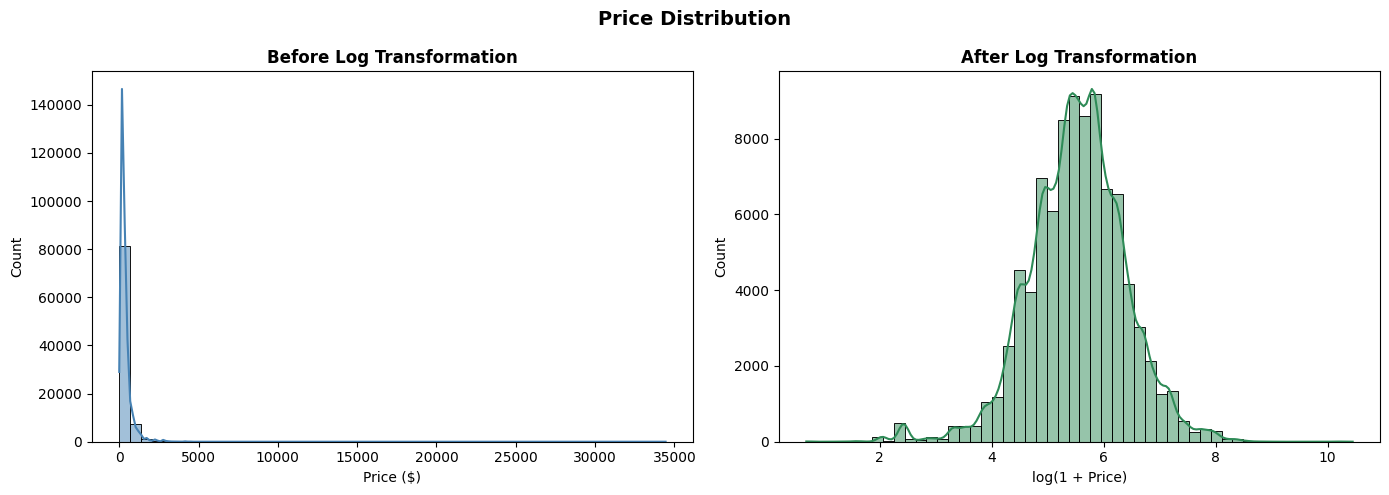

Mean price   : $362.21
Median price : $258.77
Max price    : $34448.60


In [22]:
# Cell 6: EDA: price Distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Price Distribution', fontsize=14, fontweight='bold')

sns.histplot(df['price'], kde=True, color='steelblue',
             bins=50, ax=axes[0])
axes[0].set_title('Before Log Transformation', fontweight='bold')
axes[0].set_xlabel('Price ($)')

sns.histplot(np.log1p(df['price']), kde=True, color='seagreen',
             bins=50, ax=axes[1])
axes[1].set_title('After Log Transformation', fontweight='bold')
axes[1].set_xlabel('log(1 + Price)')

plt.tight_layout()
plt.show()

print(f"Mean price   : ${df['price'].mean():.2f}")
print(f"Median price : ${df['price'].median():.2f}")
print(f"Max price    : ${df['price'].max():.2f}")

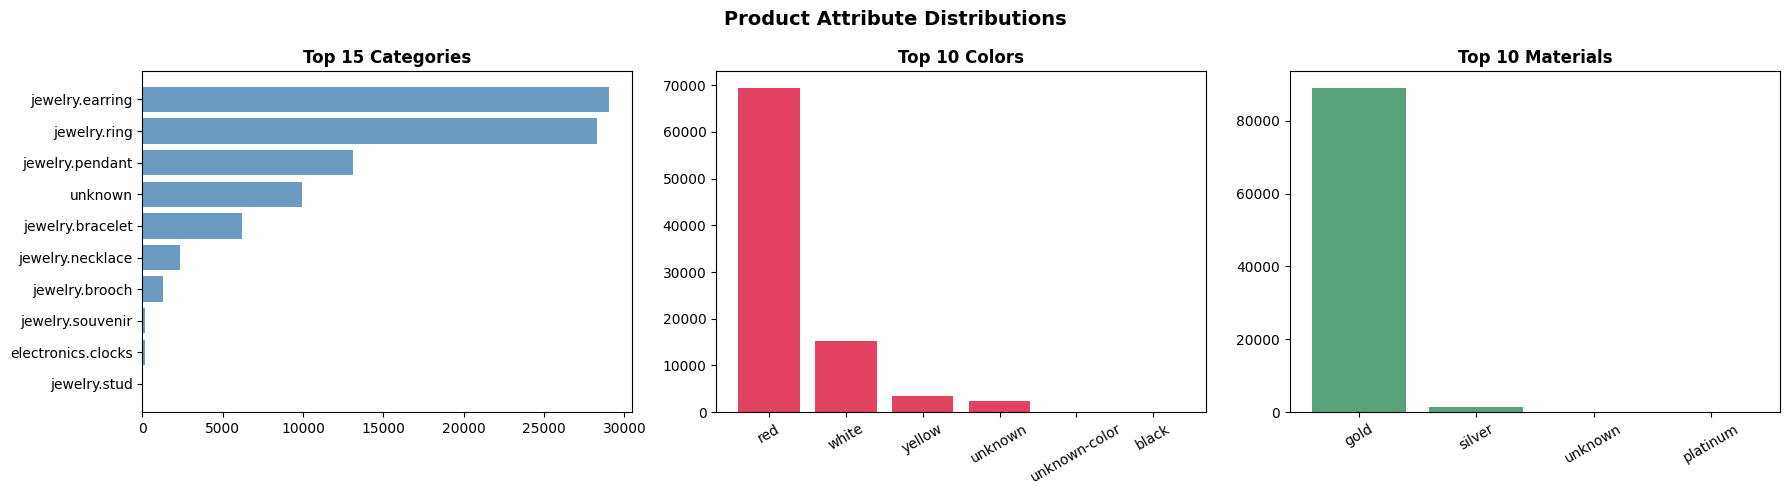

In [23]:
# CELL 7 — EDA: Category, Color, Material Distribution

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Product Attribute Distributions', fontsize=14, fontweight='bold')

# Top 15 categories
cat_counts = df['category_code'].value_counts().head(15)
axes[0].barh(cat_counts.index, cat_counts.values, color='steelblue', alpha=0.8)
axes[0].set_title('Top 15 Categories', fontweight='bold')
axes[0].invert_yaxis()

# Color distribution
col_counts = df['color'].value_counts().head(10)
axes[1].bar(col_counts.index, col_counts.values, color='crimson', alpha=0.8)
axes[1].set_title('Top 10 Colors', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

# Material distribution
mat_counts = df['material'].value_counts().head(10)
axes[2].bar(mat_counts.index, mat_counts.values, color='seagreen', alpha=0.8)
axes[2].set_title('Top 10 Materials', fontweight='bold')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

=== Purchase Behavior ===
Total purchase events      : 90,557
Users with purchases       : 25
Single-purchase users      : 2 (8.0%)
Multi-purchase users       : 23 (92.0%)


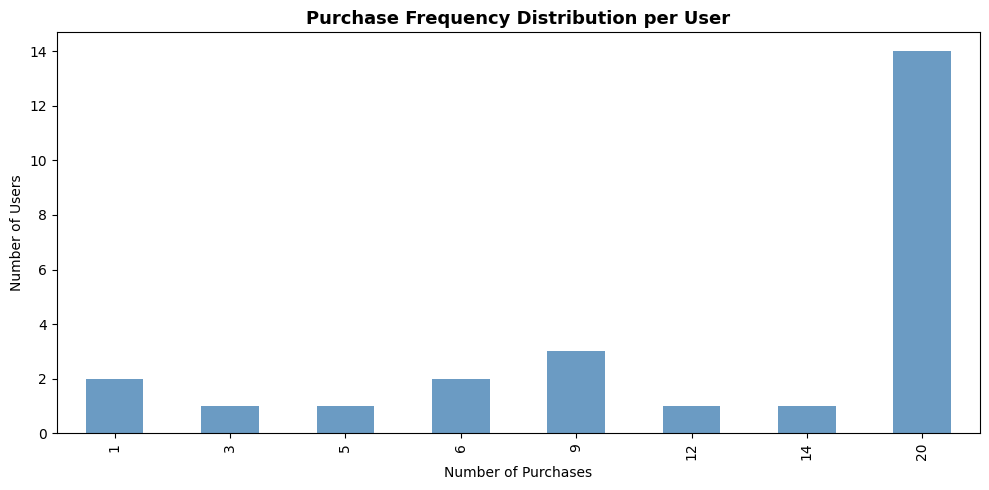

In [24]:
#CELL 8 — EDA: Purchase Behavior

# Purchases per user
purchases_per_user = df[df['is_purchase'] == 1].groupby('user_id').size()

print("=== Purchase Behavior ===")
print(f"Total purchase events      : {df['is_purchase'].sum():,}")
print(f"Users with purchases       : {purchases_per_user.shape[0]:,}")
print(f"Single-purchase users      : {(purchases_per_user == 1).sum():,} "
      f"({(purchases_per_user == 1).mean()*100:.1f}%)")
print(f"Multi-purchase users       : {(purchases_per_user > 1).sum():,} "
      f"({(purchases_per_user > 1).mean()*100:.1f}%)")

plt.figure(figsize=(10, 5))
purchases_per_user.clip(upper=20).value_counts().sort_index().plot(
    kind='bar', color='steelblue', alpha=0.8)
plt.title('Purchase Frequency Distribution per User',
          fontsize=13, fontweight='bold')
plt.xlabel('Number of Purchases')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.show()

In [25]:
# CELL 9 — Feature Engineering
df['Revenue'] = df['price']  # every priced event counts
reference_date = df['event_time'].max() + pd.Timedelta(days=1)
print(f"Reference date: {reference_date}")
print(f"Unique users  : {df['user_id'].nunique():,}")

# Transactional features — ALL events per user
trans_df = df.groupby('user_id').agg(
    total_purchase_amount   = ('price',      'sum'),
    num_purchases           = ('product_id', 'nunique'),
    avg_order_value         = ('price',      'mean'),
    total_items             = ('product_id', 'count'),
    recency_days            = ('event_time', lambda x: (reference_date - x.max()).days),
    first_purchase_gap_days = ('event_time', lambda x: (x.max() - x.min()).days)
).reset_index()

# Behavioral features
beh_df = df.groupby('user_id').agg(
    sessions_per_user  = ('event_time', lambda x: x.dt.date.nunique()),
    category_diversity = ('category_code', 'nunique'),
    color_diversity    = ('color',         'nunique'),
    total_events       = ('product_id',    'count'),
    cart_events        = ('cart_flag',     lambda x: pd.to_numeric(x, errors='coerce').sum())
).reset_index()

# Top category per user
top_cat = (df.groupby(['user_id', 'category_code'])
             .size().reset_index(name='freq')
             .sort_values('freq', ascending=False)
             .drop_duplicates('user_id')
             [['user_id', 'category_code']]
             .rename(columns={'category_code': 'top_category'}))

# Merge
hybrid_df = trans_df.merge(beh_df,   on='user_id', how='inner')
hybrid_df = hybrid_df.merge(top_cat, on='user_id', how='left')

hybrid_df['conversion_rate']       = (hybrid_df['num_purchases'] /
                                      (hybrid_df['sessions_per_user'] + 1))
hybrid_df['avg_items_per_order']   = (hybrid_df['total_items'] /
                                      (hybrid_df['num_purchases'] + 1))
hybrid_df['cart_abandonment_rate'] = 1 - hybrid_df['conversion_rate']

# Remove users with zero total spend
hybrid_df = hybrid_df[hybrid_df['total_purchase_amount'] > 0].copy()

print(f"\nHybrid feature matrix : {hybrid_df.shape}")
print(f"Unique customers      : {hybrid_df['user_id'].nunique():,}")
print(f"\ntop_category distribution:")
print(hybrid_df['top_category'].value_counts().head(10))

Reference date: 2021-12-02 09:59:07+00:00
Unique users  : 25

Hybrid feature matrix : (25, 16)
Unique customers      : 25

top_category distribution:
top_category
unknown               7
jewelry.earring       4
jewelry.pendant       3
jewelry.bracelet      2
jewelry.ring          2
jewelry.necklace      2
electronics.clocks    2
jewelry.brooch        1
jewelry.stud          1
jewelry.souvenir      1
Name: count, dtype: int64


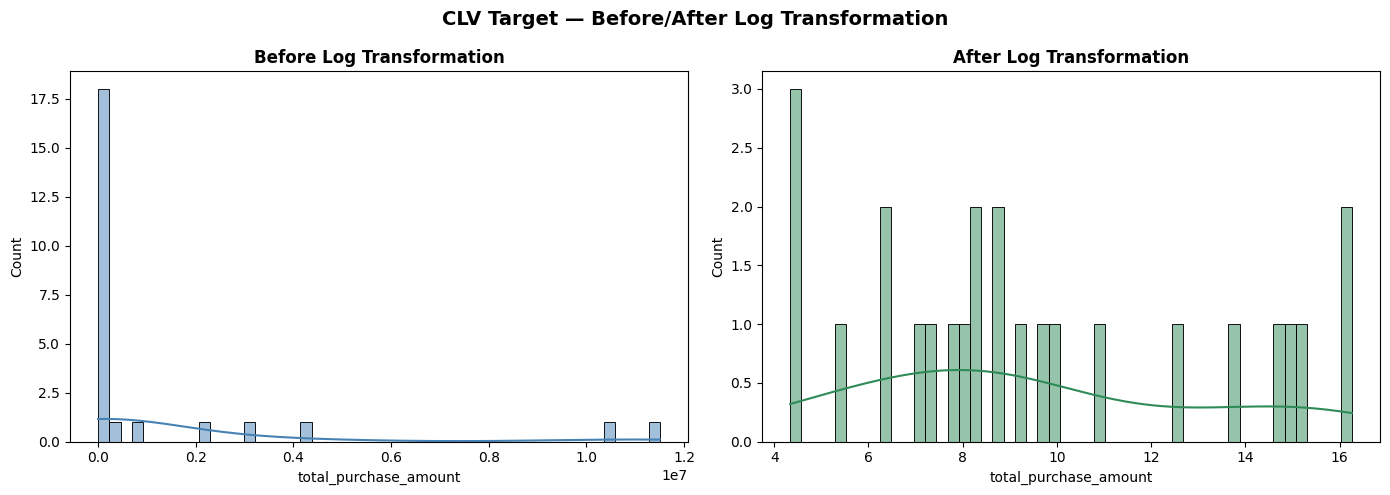

Mean CLV   : $1312042.97
Median CLV : $6255.06
Total users: 25

Skipping outlier removal — only 25 users


In [26]:
# CELL 10 — CLV Distribution + Outlier Removal

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CLV Target — Before/After Log Transformation',
             fontsize=14, fontweight='bold')

sns.histplot(hybrid_df['total_purchase_amount'], kde=True,
             color='steelblue', bins=50, ax=axes[0])
axes[0].set_title('Before Log Transformation', fontweight='bold')

sns.histplot(np.log1p(hybrid_df['total_purchase_amount']), kde=True,
             color='seagreen', bins=50, ax=axes[1])
axes[1].set_title('After Log Transformation', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Mean CLV   : ${hybrid_df['total_purchase_amount'].mean():.2f}")
print(f"Median CLV : ${hybrid_df['total_purchase_amount'].median():.2f}")
print(f"Total users: {len(hybrid_df):,}")

# Only remove outliers if enough users exist
if len(hybrid_df) > 100:
    threshold = hybrid_df['total_purchase_amount'].quantile(0.99)
    print(f"\n99th Percentile : ${threshold:.2f}")
    print(f"Users before    : {len(hybrid_df):,}")
    hybrid_df = hybrid_df[
        hybrid_df['total_purchase_amount'] <= threshold].copy()
    print(f"Users after     : {len(hybrid_df):,}")
else:
    print(f"\nSkipping outlier removal — only {len(hybrid_df)} users")

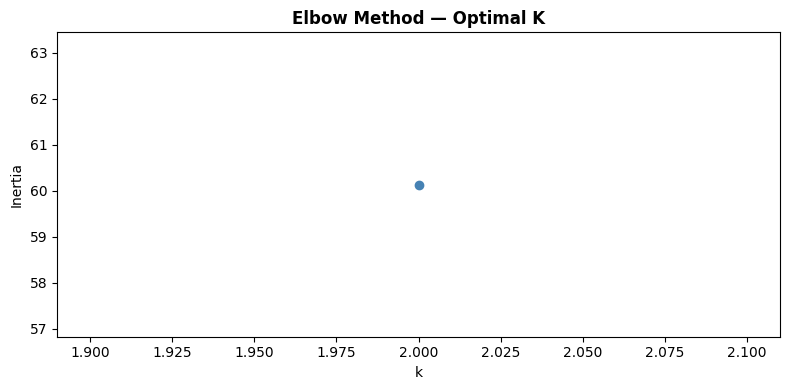

Using k=2 based on dataset size of 25 users

Clustering complete.
customer_segment
0    23
1     2
Name: count, dtype: int64

=== Cluster Profile ===
                  num_purchases  avg_order_value  total_items  recency_days  \
customer_segment                                                              
0                        113.13           246.95      1446.57         46.09   
1                       2835.00           381.34     28643.00          1.00   

                  category_diversity  conversion_rate  total_purchase_amount  
customer_segment                                                              
0                                1.0             0.45              475863.00  
1                                1.0             2.67            10928112.61  


In [28]:
# CELL 11 — K-Means Segmentation

cluster_features = ['num_purchases', 'avg_order_value',
                    'total_items', 'recency_days',
                    'category_diversity', 'conversion_rate']

# Fill any NaN before clustering
hybrid_df[cluster_features] = hybrid_df[cluster_features].fillna(0)

X_cluster        = hybrid_df[cluster_features].copy()
scaler_cluster   = StandardScaler()
X_scaled_cluster = scaler_cluster.fit_transform(X_cluster)

# Determine max k based on dataset size
max_k    = min(8, len(hybrid_df) // 10)
K_range  = range(2, max_k + 1)

inertia = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled_cluster)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), inertia, marker='o', color='steelblue')
plt.title('Elbow Method — Optimal K', fontweight='bold')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

# Choose k=4 if enough users, else k=2
n_clusters = 4 if len(hybrid_df) >= 200 else 2
print(f"Using k={n_clusters} based on dataset size of {len(hybrid_df)} users")

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
hybrid_df['customer_segment'] = kmeans.fit_predict(X_scaled_cluster)

print("\nClustering complete.")
print(hybrid_df['customer_segment'].value_counts().sort_index())
print("\n=== Cluster Profile ===")
print(hybrid_df.groupby('customer_segment')[
    cluster_features + ['total_purchase_amount']].mean().round(2))

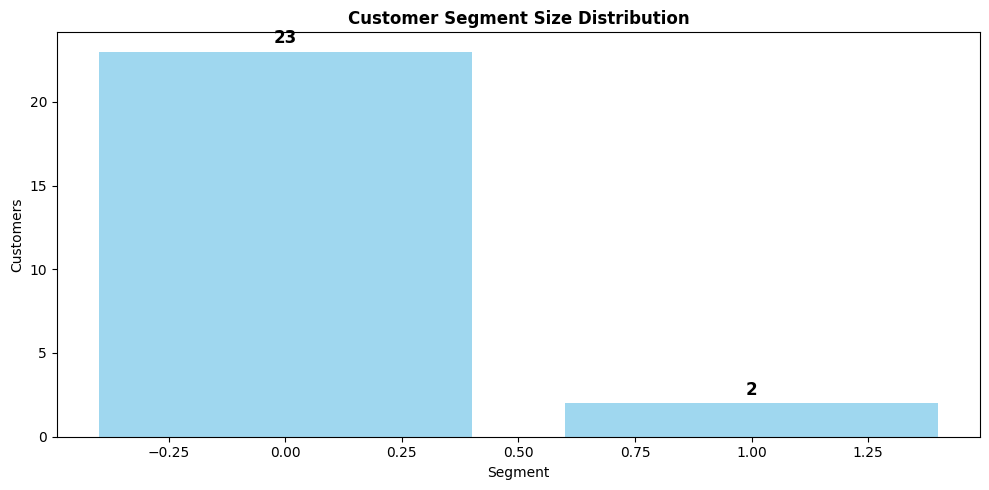

In [29]:
# CELL 12 — Segment Size Chart

plt.figure(figsize=(10, 5))
seg_counts = hybrid_df['customer_segment'].value_counts().sort_index()
bars = plt.bar(seg_counts.index, seg_counts.values,
               color='skyblue', alpha=0.8)
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 0.5,
             f'{h:,}', ha='center', fontweight='bold', fontsize=12)
plt.title('Customer Segment Size Distribution', fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Customers')
plt.tight_layout()
plt.show()

In [30]:
# CELL 13 — Segmented XGBoost

feature_columns = ['num_purchases', 'avg_order_value', 'total_items',
                   'recency_days', 'first_purchase_gap_days',
                   'sessions_per_user', 'category_diversity',
                   'conversion_rate', 'avg_items_per_order',
                   'cart_abandonment_rate', 'cart_events',
                   'color_diversity']

# Fill NaN in all feature columns
hybrid_df[feature_columns] = hybrid_df[feature_columns].fillna(0)

segment_metrics = {}
MIN_SEG_SAMPLES = 10  # lowered threshold for small dataset

print("=" * 50)
print("Hybrid XGBoost — Segment-wise CLV Modelling")
print("=" * 50)

for seg in sorted(hybrid_df['customer_segment'].unique()):
    df_seg = hybrid_df[hybrid_df['customer_segment'] == seg].copy()

    if len(df_seg) < MIN_SEG_SAMPLES:
        print(f"\nSegment {seg} skipped — only {len(df_seg)} users")
        continue

    X = df_seg[feature_columns].copy().fillna(0)
    y = np.log1p(df_seg['total_purchase_amount'])

    # Need at least 2 unique values to split
    if y.nunique() < 2:
        print(f"\nSegment {seg} skipped — insufficient target variance")
        continue

    scaler_seg = MinMaxScaler()
    X_scaled   = pd.DataFrame(scaler_seg.fit_transform(X),
                               columns=feature_columns)

    # Adjust test size for small segments
    test_sz = 0.2 if len(df_seg) >= 50 else 0.3

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y, test_size=test_sz, random_state=42)

    model = xgb.XGBRegressor(n_estimators=100, max_depth=4,
                              learning_rate=0.1, random_state=42)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    y_pred_orig = np.expm1(y_pred)
    y_te_orig   = np.expm1(y_te)

    rmse = np.sqrt(mean_squared_error(y_te_orig, y_pred_orig))
    mae  = mean_absolute_error(y_te_orig, y_pred_orig)
    r2   = r2_score(y_te, y_pred)

    segment_metrics[seg] = {
        'RMSE': rmse, 'MAE': mae, 'R2': r2,
        'model': model, 'X_test': X_te,
        'y_test': y_te, 'n_users': len(df_seg)
    }

    print(f"\nSegment {seg} ({len(df_seg):,} users)")
    print(f"  RMSE : ${rmse:.4f}")
    print(f"  MAE  : ${mae:.4f}")
    print(f"  R²   : {r2:.4f}")

if segment_metrics:
    print("\n" + "=" * 50)
    print(f"Average RMSE : ${np.mean([v['RMSE'] for v in segment_metrics.values()]):.4f}")
    print(f"Average MAE  : ${np.mean([v['MAE']  for v in segment_metrics.values()]):.4f}")
    print(f"Average R²   : {np.mean([v['R2']    for v in segment_metrics.values()]):.4f}")
else:
    print("\n⚠️ No segments trained — check dataset size")

Hybrid XGBoost — Segment-wise CLV Modelling

Segment 0 (23 users)
  RMSE : $1542041.5024
  MAE  : $661789.7228
  R²   : 0.9049

Segment 1 skipped — only 2 users

Average RMSE : $1542041.5024
Average MAE  : $661789.7228
Average R²   : 0.9049


In [31]:
# CELL 14 — Category-Based XGBoost

df_category = hybrid_df.dropna(subset=['top_category'])
df_category = df_category[df_category['top_category'] != 'unknown'].copy()

print(f"Samples    : {len(df_category):,}")
print(f"Categories : {df_category['top_category'].nunique()}")
print(f"\nCategory distribution:")
print(df_category['top_category'].value_counts())

cat_counts  = df_category['top_category'].value_counts()

# Dynamic threshold
if   (cat_counts >= 50).sum() >= 3:
    MIN_CAT = 50
elif (cat_counts >= 20).sum() >= 3:
    MIN_CAT = 20
elif (cat_counts >= 10).sum() >= 3:
    MIN_CAT = 10
else:
    MIN_CAT = 5

print(f"\nUsing minimum sample threshold: {MIN_CAT}")

category_results = []
skipped = 0

for cat in df_category['top_category'].unique():
    df_cat = df_category[df_category['top_category'] == cat].copy()

    if len(df_cat) < MIN_CAT:
        skipped += 1
        continue

    X = df_cat[feature_columns].copy().fillna(0)
    y = np.log1p(df_cat['total_purchase_amount'])

    if y.nunique() < 2:
        skipped += 1
        continue

    scaler_cat = MinMaxScaler()
    X_scaled   = pd.DataFrame(scaler_cat.fit_transform(X),
                               columns=feature_columns)

    test_sz = 0.2 if len(df_cat) >= 50 else 0.3

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y, test_size=test_sz, random_state=42)

    model = xgb.XGBRegressor(n_estimators=100, max_depth=4,
                              learning_rate=0.1, random_state=42)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    y_pred_orig = np.expm1(y_pred)
    y_te_orig   = np.expm1(y_te)

    category_results.append({
        'Category': cat,
        'Samples' : len(df_cat),
        'RMSE'    : np.sqrt(mean_squared_error(y_te_orig, y_pred_orig)),
        'MAE'     : mean_absolute_error(y_te_orig, y_pred_orig),
        'R2'      : r2_score(y_te, y_pred)
    })

    print(f"\nCategory: {cat} ({len(df_cat):,} users)")
    print(f"  RMSE : ${category_results[-1]['RMSE']:.4f}")
    print(f"  R²   : {category_results[-1]['R2']:.4f}")

if len(category_results) == 0:
    print("\n⚠️ No categories met the threshold.")
    print("This dataset may be too small for category-level modeling.")
    print("Consider using the full dataset without category splitting.")
else:
    category_results_df = pd.DataFrame(category_results)
    total_cats   = df_category['top_category'].nunique()
    modeled_cats = len(category_results_df)

    print("\n" + "=" * 60)
    print("CATEGORY MODELING SUMMARY")
    print("=" * 60)
    print(f"Total categories         : {total_cats}")
    print(f"Categories modeled       : {modeled_cats}")
    print(f"Categories skipped       : {skipped}")
    print(f"Modeling success rate    : {modeled_cats/total_cats*100:.1f}%")
    print(f"Average RMSE             : ${category_results_df['RMSE'].mean():.4f}")
    print(f"Average R²               : {category_results_df['R2'].mean():.4f}")
    print("=" * 60)

    top_10 = category_results_df.sort_values('RMSE').head(10)
    print(f"\n{'Rank':<5} {'Category':<25} {'Samples':<10} "
          f"{'RMSE ($)':<12} {'R²':<10}")
    print("-" * 65)
    for i, (_, row) in enumerate(top_10.iterrows(), 1):
        print(f"{i:<5} {row['Category']:<25} {int(row['Samples']):<10} "
              f"{row['RMSE']:<12.4f} {row['R2']:<10.4f}")

Samples    : 18
Categories : 9

Category distribution:
top_category
jewelry.earring       4
jewelry.pendant       3
jewelry.bracelet      2
jewelry.ring          2
jewelry.necklace      2
electronics.clocks    2
jewelry.brooch        1
jewelry.stud          1
jewelry.souvenir      1
Name: count, dtype: int64

Using minimum sample threshold: 5

⚠️ No categories met the threshold.
This dataset may be too small for category-level modeling.
Consider using the full dataset without category splitting.


In [32]:
# CELL 15 — Session Feature Engineering

print("Creating session-level features...")

session_df = df.groupby(
    ['user_id', df['event_time'].dt.date]
).agg(
    session_revenue       = ('price',      'sum'),
    items_in_session      = ('product_id', 'count'),
    unique_products       = ('product_id', 'nunique'),
    session_date          = ('event_time', 'min'),
    session_duration_mins = ('event_time',
                             lambda x: (x.max()-x.min()).seconds/60),
    is_purchase           = ('is_purchase','max')
).reset_index(level=1, drop=True).reset_index()

print(f"Sessions created  : {len(session_df):,}")
print(f"Unique customers  : {session_df['user_id'].nunique():,}")
print(session_df.head())

Creating session-level features...
Sessions created  : 6,898
Unique customers  : 25
               user_id  session_revenue  items_in_session  unique_products  \
0  1313677631836652032           314.38                 1                1   
1  1313677631836652032            63.93                 1                1   
2  1313677631836652032           136.99                 1                1   
3  1313677631836652032           136.99                 1                1   
4  1313677631836652032           178.48                 2                1   

               session_date  session_duration_mins  is_purchase  
0 2021-06-15 11:14:02+00:00               0.000000            1  
1 2021-08-15 13:37:54+00:00               0.000000            1  
2 2021-08-27 08:25:16+00:00               0.000000            1  
3 2021-09-03 14:28:02+00:00               0.000000            1  
4 2021-11-12 13:58:35+00:00               8.183333            1  


In [33]:
# CELL 16 — Session-Based XGBoost (Cold-Start)
sess_agg = session_df.groupby('user_id').agg(
    total_items_sess      = ('items_in_session', 'sum'),
    avg_items_per_session = ('items_in_session', 'mean'),
    unique_products_sess  = ('unique_products',  'sum'),
    total_sessions        = ('session_date',     'nunique'),
    avg_session_duration  = ('session_duration_mins', 'mean'),
    purchase_sessions     = ('is_purchase',      'sum')
).reset_index()

sess_model_df = sess_agg.merge(
    hybrid_df[['user_id', 'total_purchase_amount']],
    on='user_id', how='inner')

print(f"Session dataset   : {len(sess_model_df):,} users")

if len(sess_model_df) < 10:
    print("⚠️ Too few users for session model — skipping")
    rmse_sess = mae_sess = r2_sess = None
else:
    sess_cols = ['total_items_sess', 'avg_items_per_session',
                 'unique_products_sess', 'total_sessions',
                 'avg_session_duration', 'purchase_sessions']

    X_sess        = sess_model_df[sess_cols].fillna(0)
    y_sess        = np.log1p(sess_model_df['total_purchase_amount'])
    scaler_sess   = MinMaxScaler()
    X_sess_scaled = pd.DataFrame(scaler_sess.fit_transform(X_sess),
                                   columns=sess_cols)

    test_sz = 0.2 if len(sess_model_df) >= 50 else 0.3

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_sess_scaled, y_sess, test_size=test_sz, random_state=42)

    sess_xgb = xgb.XGBRegressor(n_estimators=100, max_depth=4,
                                  learning_rate=0.1, random_state=42)
    sess_xgb.fit(X_tr, y_tr)
    y_pred_sess = sess_xgb.predict(X_te)

    y_pred_orig = np.expm1(y_pred_sess)
    y_te_orig   = np.expm1(y_te)

    rmse_sess = np.sqrt(mean_squared_error(y_te_orig, y_pred_orig))
    mae_sess  = mean_absolute_error(y_te_orig, y_pred_orig)
    r2_sess   = r2_score(y_te, y_pred_sess)

    print("\n── Session-Based XGBoost (Cold-Start) ───────────")
    print(f"  RMSE : ${rmse_sess:.4f}")
    print(f"  MAE  : ${mae_sess:.4f}")
    print(f"  R²   : {r2_sess:.4f}")

Session dataset   : 25 users

── Session-Based XGBoost (Cold-Start) ───────────
  RMSE : $1070916.0440
  MAE  : $541427.4110
  R²   : 0.8391


In [34]:
# CELL 17 — Sequential LSTM Prep

MAX_SESSIONS = 10
SEQ_FEATURES = ['items_in_session', 'unique_products',
                'is_purchase', 'session_duration_mins']

session_df_sorted = session_df.sort_values(['user_id', 'session_date'])
clv_lookup        = hybrid_df[['user_id', 'total_purchase_amount']]
users_with_clv    = clv_lookup['user_id'].values

print("Building session sequences...")
sequences, targets, users_seq = [], [], []

for cust_id in users_with_clv:
    cust_sess = session_df_sorted[
        session_df_sorted['user_id'] == cust_id][SEQ_FEATURES].values

    if len(cust_sess) == 0:
        continue

    if len(cust_sess) >= MAX_SESSIONS:
        seq = cust_sess[-MAX_SESSIONS:]
    else:
        pad = np.zeros((MAX_SESSIONS - len(cust_sess), len(SEQ_FEATURES)))
        seq = np.vstack([pad, cust_sess])

    clv_vals = clv_lookup[clv_lookup['user_id'] == cust_id][
        'total_purchase_amount'].values
    if len(clv_vals) == 0:
        continue

    sequences.append(seq)
    targets.append(np.log1p(clv_vals[0]))
    users_seq.append(cust_id)

X_seq = np.array(sequences, dtype=np.float32)
y_seq = np.array(targets,   dtype=np.float32)

print(f"Sequence array : {X_seq.shape}")
print(f"Target array   : {y_seq.shape}")
print(f"Users in seq   : {len(users_seq):,}")

Building session sequences...
Sequence array : (25, 10, 4)
Target array   : (25,)
Users in seq   : 25


Model: "Sequential_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,777 (77.25 KB)

 Trainable params: 19,777 (77.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 408ms/step - loss: 101.7288 - val_loss: 156.2287
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 100.3079 - val_loss: 154.3042
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 98.8064 - val_loss: 152.7347
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 97.6390 - val_loss: 150.9472
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 96.2556 - val_loss: 148.9039
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 94.8843 - val_loss: 146.5451
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 93.1304 - val_loss: 143.7260
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 91.2453 - val_loss: 140.2787
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 89.0163 - val_loss: 136.0949
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 85.3583 - val_loss: 131.1844
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 82.4001 - val_loss: 124.9038
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/ste

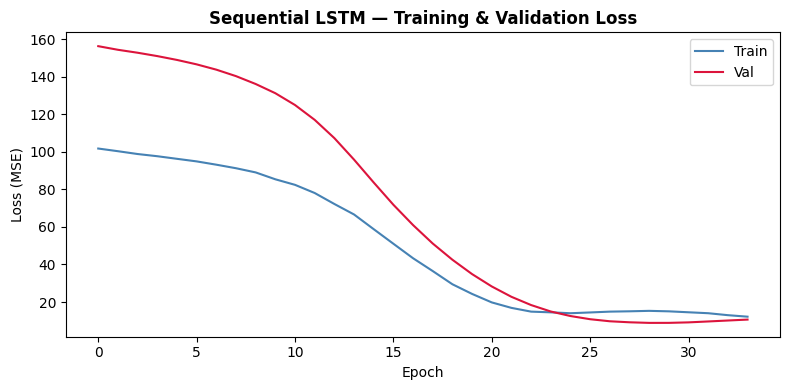

In [35]:
# CELL 18 — Sequential LSTM Training

if len(X_seq) < 20:
    print("⚠️ Too few sequences for LSTM — skipping")
    rmse_lstm = mae_lstm = r2_lstm = None
else:
    X_seq_flat = X_seq.reshape(-1, len(SEQ_FEATURES))
    scaler_seq  = MinMaxScaler()
    X_seq_norm  = scaler_seq.fit_transform(X_seq_flat).reshape(X_seq.shape)

    n       = len(X_seq_norm)
    train_i = int(n * 0.8)
    X_tr_s  = X_seq_norm[:train_i];  X_te_s = X_seq_norm[train_i:]
    y_tr_s  = y_seq[:train_i];       y_te_s = y_seq[train_i:]

    lstm_model = tf.keras.Sequential([
        Input(shape=(MAX_SESSIONS, len(SEQ_FEATURES)), name='seq_input'),
        LSTM(64),
        Dense(32, activation='relu'),
        Dense(1)
    ], name='Sequential_LSTM')

    lstm_model.compile(optimizer='adam', loss='mse')
    lstm_model.summary()

    history = lstm_model.fit(
        X_tr_s, y_tr_s,
        validation_split=0.2,
        epochs=50,
        batch_size=max(8, len(X_tr_s)//10),  # dynamic batch size
        callbacks=[EarlyStopping(monitor='val_loss', patience=5,
                                  restore_best_weights=True)],
        verbose=1
    )

    y_lstm_pred = lstm_model.predict(X_te_s).flatten()
    y_lstm_orig = np.expm1(y_lstm_pred)
    y_te_s_orig = np.expm1(y_te_s)

    rmse_lstm = np.sqrt(mean_squared_error(y_te_s_orig, y_lstm_orig))
    mae_lstm  = mean_absolute_error(y_te_s_orig, y_lstm_orig)
    r2_lstm   = r2_score(y_te_s, y_lstm_pred)

    print(f"\n── Sequential LSTM ───────────")
    print(f"  RMSE : ${rmse_lstm:.4f}")
    print(f"  MAE  : ${mae_lstm:.4f}")
    print(f"  R²   : {r2_lstm:.4f}")

    plt.figure(figsize=(8, 4))
    plt.plot(history.history['loss'],     label='Train', color='steelblue')
    plt.plot(history.history['val_loss'], label='Val',   color='crimson')
    plt.title('Sequential LSTM — Training & Validation Loss',
              fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.tight_layout()
    plt.show()

Model: "Hybrid_LSTM_FeatureFusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 10, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_input        │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     17,664 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │        288 │ static_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 16)        │        528 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 48)        │          0 │ dense_2[0][0],    │
│ (Concatenate)       │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 32)        │      1,568 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1)         │         33 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 22,161 (86.57 KB)

 Trainable params: 22,161 (86.57 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 324ms/step - loss: 102.6315 - val_loss: 157.5183
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 101.1069 - val_loss: 154.5210
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 98.6651 - val_loss: 151.4335
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 96.2296 - val_loss: 148.4090
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 94.9129 - val_loss: 145.1856
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 92.0939 - val_loss: 141.7018
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 88.7878 - val_loss: 137.6028
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 86.4991 - val_loss: 132.3582
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 81.9889 - val_loss: 125.8792
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 76.9007 - val_loss: 117.6354
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 73.2515 - val_loss: 107.0627
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/

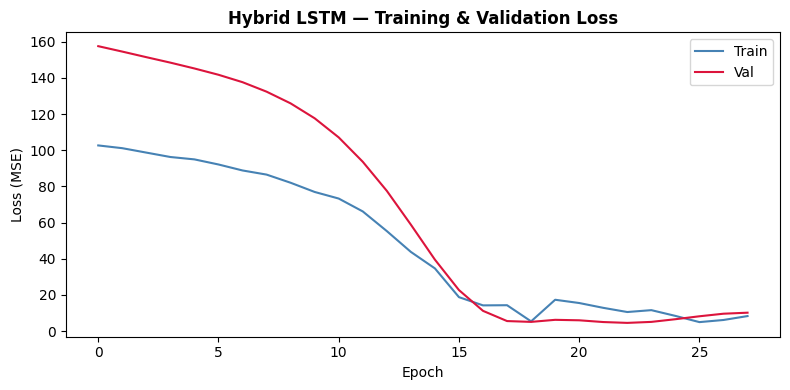

In [36]:
# CELL 19 — Hybrid LSTM Feature Fusion

if len(X_seq) < 20:
    print("⚠️ Too few sequences for Hybrid LSTM — skipping")
    rmse_hybrid = mae_hybrid = r2_hybrid = None
else:
    static_cols = ['avg_order_value', 'num_purchases', 'total_items',
                   'recency_days', 'first_purchase_gap_days',
                   'category_diversity', 'conversion_rate',
                   'avg_items_per_order']

    hybrid_seq_df = (hybrid_df[hybrid_df['user_id'].isin(users_seq)]
                     .set_index('user_id').loc[users_seq].reset_index())

    X_static      = hybrid_seq_df[static_cols].fillna(0).values.astype(np.float32)
    scaler_static = MinMaxScaler()
    X_static_norm = scaler_static.fit_transform(X_static)

    X_seq_tr_h  = X_seq_norm[:train_i];   X_seq_te_h  = X_seq_norm[train_i:]
    X_static_tr = X_static_norm[:train_i]; X_static_te = X_static_norm[train_i:]

    seq_in   = Input(shape=(MAX_SESSIONS, len(SEQ_FEATURES)), name='seq_input')
    lstm_out = LSTM(64)(seq_in)
    lstm_out = Dense(32, activation='relu')(lstm_out)

    stat_in  = Input(shape=(len(static_cols),), name='static_input')
    stat_out = Dense(32, activation='relu')(stat_in)
    stat_out = Dense(16, activation='relu')(stat_out)

    merged   = Concatenate()([lstm_out, stat_out])
    merged   = Dense(32, activation='relu')(merged)
    merged   = Dropout(0.2)(merged)
    output   = Dense(1)(merged)

    hybrid_lstm = Model(inputs=[seq_in, stat_in], outputs=output,
                        name='Hybrid_LSTM_FeatureFusion')
    hybrid_lstm.compile(optimizer='adam', loss='mse')
    hybrid_lstm.summary()

    history_h = hybrid_lstm.fit(
        [X_seq_tr_h, X_static_tr], y_tr_s,
        validation_split=0.2,
        epochs=50,
        batch_size=max(8, len(X_seq_tr_h)//10),
        callbacks=[EarlyStopping(monitor='val_loss', patience=5,
                                  restore_best_weights=True)],
        verbose=1
    )

    y_hybrid_pred = hybrid_lstm.predict(
        [X_seq_te_h, X_static_te]).flatten()
    y_hybrid_orig = np.expm1(y_hybrid_pred)

    rmse_hybrid = np.sqrt(mean_squared_error(y_te_s_orig, y_hybrid_orig))
    mae_hybrid  = mean_absolute_error(y_te_s_orig, y_hybrid_orig)
    r2_hybrid   = r2_score(y_te_s, y_hybrid_pred)

    print(f"\n── Hybrid LSTM Fusion ───────────")
    print(f"  RMSE : ${rmse_hybrid:.4f}")
    print(f"  MAE  : ${mae_hybrid:.4f}")
    print(f"  R²   : {r2_hybrid:.4f}")

    plt.figure(figsize=(8, 4))
    plt.plot(history_h.history['loss'],     label='Train', color='steelblue')
    plt.plot(history_h.history['val_loss'], label='Val',   color='crimson')
    plt.title('Hybrid LSTM — Training & Validation Loss',
              fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [37]:
# CELL 20 — Final Benchmark

X_all        = hybrid_df[feature_columns].fillna(0).copy()
y_all        = np.log1p(hybrid_df['total_purchase_amount'])
scaler_all   = MinMaxScaler()
X_all_scaled = pd.DataFrame(scaler_all.fit_transform(X_all),
                              columns=feature_columns)

test_sz = 0.2 if len(hybrid_df) >= 50 else 0.3

X_train, X_test, y_train, y_test = train_test_split(
    X_all_scaled, y_all, test_size=test_sz, random_state=42)

benchmark_metrics = {}

# 1. Mean Baseline
y_mean = np.full(len(y_test), y_train.mean())
benchmark_metrics['Mean Baseline'] = {
    'RMSE': np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_mean))),
    'MAE' : mean_absolute_error(np.expm1(y_test), np.expm1(y_mean)),
    'R2'  : r2_score(y_test, y_mean)
}

# 2. Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_lr = lr.predict(X_test)
benchmark_metrics['Linear Regression'] = {
    'RMSE': np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_lr))),
    'MAE' : mean_absolute_error(np.expm1(y_test), np.expm1(y_lr)),
    'R2'  : r2_score(y_test, y_lr)
}

# 3. Segmented XGBoost
if segment_metrics:
    benchmark_metrics['Segmented XGBoost'] = {
        'RMSE': np.mean([v['RMSE'] for v in segment_metrics.values()]),
        'MAE' : np.mean([v['MAE']  for v in segment_metrics.values()]),
        'R2'  : np.mean([v['R2']   for v in segment_metrics.values()])
    }

# 4. Category XGBoost
if 'category_results_df' in dir() and len(category_results_df) > 0:
    benchmark_metrics['Category XGBoost'] = {
        'RMSE': category_results_df['RMSE'].mean(),
        'MAE' : category_results_df['MAE'].mean(),
        'R2'  : category_results_df['R2'].mean()
    }

# 5. Session XGBoost
if rmse_sess is not None:
    benchmark_metrics['Session XGBoost'] = {
        'RMSE': rmse_sess, 'MAE': mae_sess, 'R2': r2_sess}

# 6. Sequential LSTM
if rmse_lstm is not None:
    benchmark_metrics['Sequential LSTM'] = {
        'RMSE': rmse_lstm, 'MAE': mae_lstm, 'R2': r2_lstm}

# 7. Hybrid LSTM
if rmse_hybrid is not None:
    benchmark_metrics['Hybrid LSTM Fusion'] = {
        'RMSE': rmse_hybrid, 'MAE': mae_hybrid, 'R2': r2_hybrid}

benchmark_df = pd.DataFrame(benchmark_metrics).T.astype(float)

print("\n" + "=" * 55)
print("Final Benchmark — All Models")
print("=" * 55)
print(f"{'Model':<22} {'RMSE ($)':<12} {'MAE ($)':<12} {'R2':<10}")
print("-" * 55)
for name, row in benchmark_df.iterrows():
    print(f"{name:<22} {row['RMSE']:<12.4f} "
          f"{row['MAE']:<12.4f} {row['R2']:<10.4f}")
print("=" * 55)


Final Benchmark — All Models
Model                  RMSE ($)     MAE ($)      R2        
-------------------------------------------------------
Mean Baseline          1319299.8644 667407.4024  -0.1701   
Linear Regression      102505968.5417 37292865.4276 0.7243    
Segmented XGBoost      1542041.5024 661789.7228  0.9049    
Session XGBoost        1070916.0440 541427.4110  0.8391    
Sequential LSTM        23207.1699   21809.7559   -0.4080   
Hybrid LSTM Fusion     109678.8318  94893.0000   -0.0688   


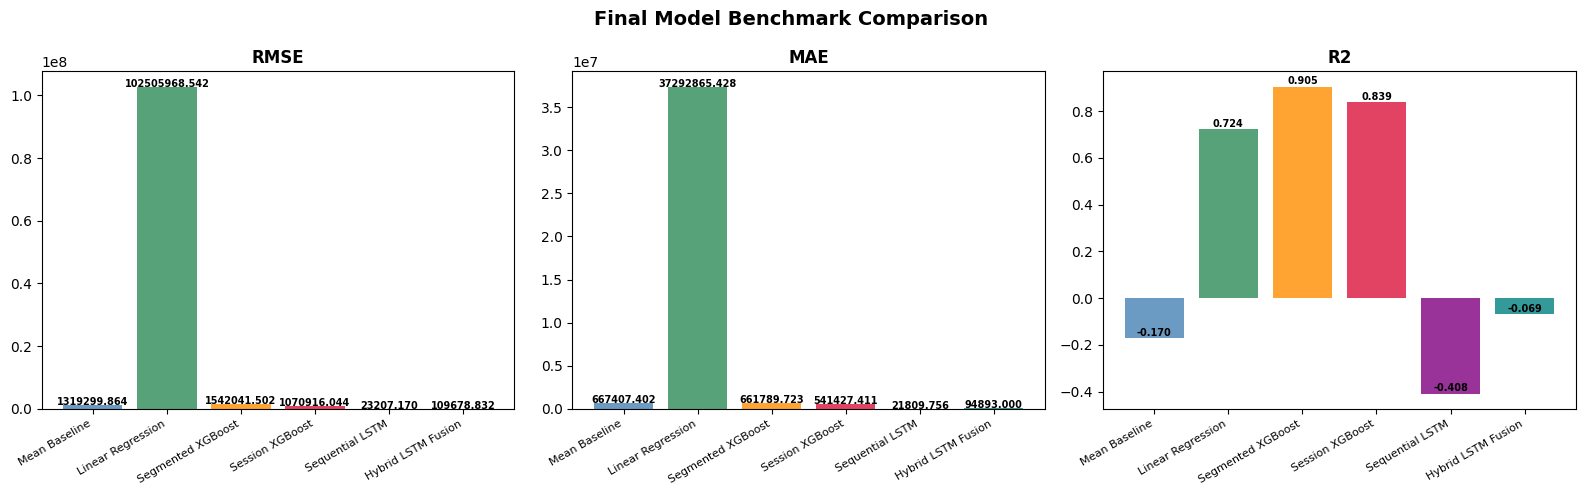

In [38]:
# CELL 21 — Benchmark Visualisation

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Final Model Benchmark Comparison',
             fontsize=14, fontweight='bold')

colors = ['steelblue','seagreen','darkorange',
          'crimson','purple','teal','gold']

for i, metric in enumerate(['RMSE', 'MAE', 'R2']):
    values = benchmark_df[metric].astype(float)
    axes[i].bar(range(len(values)), values,
                color=colors[:len(values)], alpha=0.8)
    axes[i].set_title(metric, fontweight='bold')
    axes[i].set_xticks(range(len(values)))
    axes[i].set_xticklabels(benchmark_df.index,
                             rotation=30, ha='right', fontsize=8)
    for j, val in enumerate(values):
        axes[i].text(j, val + 0.01, f'{val:.3f}',
                     ha='center', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.show()

SHAP Analysis per Segment


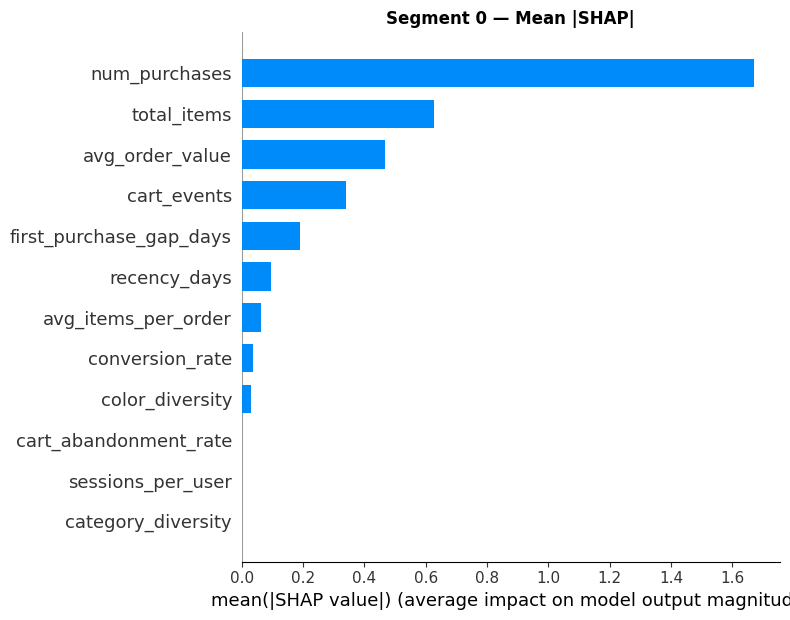

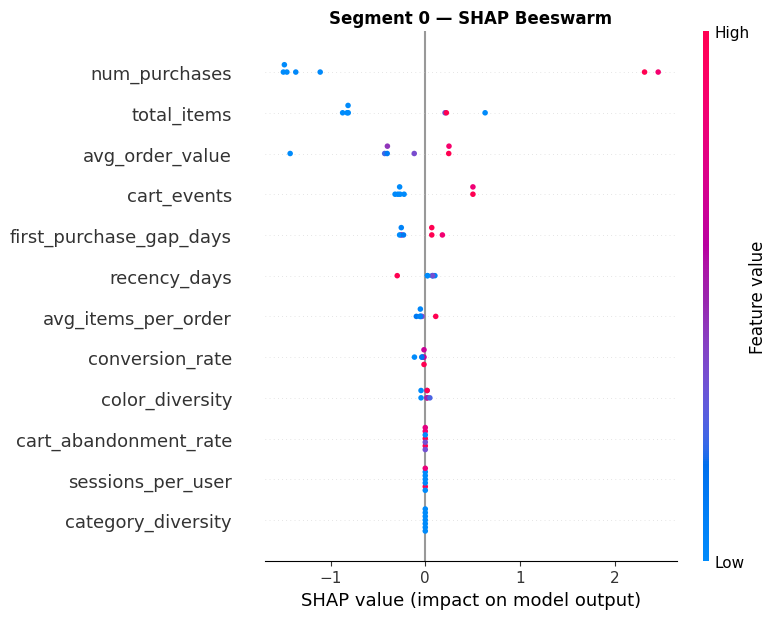

In [39]:
# CELL 22 — SHAP per Segment

if not segment_metrics:
    print("⚠️ No segment models available for SHAP")
else:
    print("=" * 50)
    print("SHAP Analysis per Segment")
    print("=" * 50)

    for seg, vals in segment_metrics.items():
        model = vals['model']
        X_te  = vals['X_test']

        explainer   = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_te)

        plt.figure(figsize=(8, 5))
        shap.summary_plot(shap_values, X_te,
                          plot_type='bar', show=False)
        plt.title(f'Segment {seg} — Mean |SHAP|', fontweight='bold')
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(8, 5))
        shap.summary_plot(shap_values, X_te, show=False)
        plt.title(f'Segment {seg} — SHAP Beeswarm', fontweight='bold')
        plt.tight_layout()
        plt.show()